# Importación de librerías

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# xgboost
import xgboost as xgb

# Guardar modelo
from joblib import dump
import joblib

# Estilo para visualizaciones
sns.set(style="whitegrid")

# Explicabilidad
import shap

/home/andresmtr/miniconda3/envs/PruebaBRM/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Carga y exploración del dataset

In [2]:
dataset = load_dataset("rajistics/electricity_demand", split="train")
df = pd.DataFrame(dataset)
print("Columnas disponibles:", df.columns)
print("Primeras filas del dataset:")
print(df.head())


Columnas disponibles: Index(['Demand', 'Temperature', '__index_level_0__'], dtype='object')
Primeras filas del dataset:
   Demand  Temperature   __index_level_0__
0   3.794        18.05 2014-01-01 00:00:00
1   3.418        17.20 2014-01-01 01:00:00
2   3.152        16.45 2014-01-01 02:00:00
3   3.026        16.65 2014-01-01 03:00:00
4   3.022        16.40 2014-01-01 04:00:00


In [3]:
df = pd.DataFrame(dataset)
print("Primeras filas del dataset:")
df.head(30)


Primeras filas del dataset:


,Demand,Temperature,__index_level_0__
0,3.794,18.05,2014-01-01 00:00:00
1,3.418,17.20,2014-01-01 01:00:00
2,3.152,16.45,2014-01-01 02:00:00
3,3.026,16.65,2014-01-01 03:00:00
4,3.022,16.40,2014-01-01 04:00:00
5,3.055,17.95,2014-01-01 05:00:00
6,3.180,19.70,2014-01-01 06:00:00
7,3.276,20.60,2014-01-01 07:00:00
8,3.467,22.35,2014-01-01 08:00:00
9,3.620,23.70,2014-01-01 09:00:00


In [4]:
df.columns

Index(['Demand', 'Temperature', '__index_level_0__'], dtype='object')

In [5]:
len(df)

1344

In [21]:
df.tail()

,Demand,Temperature,__index_level_0__,date
1339,4.968,20.10,2014-02-25 19:00:00,2014-02-25
1340,4.742,19.90,2014-02-25 20:00:00,2014-02-25
1341,4.304,19.30,2014-02-25 21:00:00,2014-02-25
1342,4.105,19.05,2014-02-25 22:00:00,2014-02-25
1343,4.410,18.85,2014-02-25 23:00:00,2014-02-25


# Preprocesamiento de los datos

In [6]:
# Preprocesamiento
df['__index_level_0__'] = pd.to_datetime(df['__index_level_0__'])
df = df.sort_values('__index_level_0__')
df['date'] = df['__index_level_0__'].dt.date

In [7]:
df.head()

,Demand,Temperature,__index_level_0__,date
0,3.794,18.05,2014-01-01 00:00:00,2014-01-01
1,3.418,17.20,2014-01-01 01:00:00,2014-01-01
2,3.152,16.45,2014-01-01 02:00:00,2014-01-01
3,3.026,16.65,2014-01-01 03:00:00,2014-01-01
4,3.022,16.40,2014-01-01 04:00:00,2014-01-01


In [8]:
# Agrupar por fecha y conservar solo los días con 48 registros (30 min x 24 horas)
daily_series = df.groupby('date')['Demand'].apply(list)
daily_series = daily_series[daily_series.apply(lambda x: len(x) == 24)]

In [9]:
# Validar si hay suficientes datos
if len(daily_series) < 2:
    raise ValueError("No hay suficientes días completos con 24 registros por hora para crear pares de entrenamiento.")


In [20]:
len(daily_series)

56

In [10]:
# Crear dataset supervisado (día N -> día N+1)
X = []
y = []
for i in range(len(daily_series) - 1):
    X.append(daily_series.iloc[i])
    y.append(daily_series.iloc[i + 1])

X = np.array(X)
y = np.array(y)

In [11]:
# Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [12]:
# Entrenar modelo Random Forest
# model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
# model.fit(X_train, y_train)

# Modelos a evaluar
models = {
    "LinearRegressionH": LinearRegression(fit_intercept=True),
    
    "DecisionTreeRegressorH": DecisionTreeRegressor(
        max_depth=20, 
        min_samples_split=5, 
        min_samples_leaf=2, 
        max_features='sqrt',
        random_state=42
    ),
    
    "RandomForestRegressorH": RandomForestRegressor(
        n_estimators=500, 
        max_depth=30,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        bootstrap=True,
        random_state=42
    ),
    
    "XGBRegressorH": xgb.XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1,
        random_state=42,
        tree_method="hist"  # Aceleración para CPU
    )
}

In [13]:
# Diccionario para almacenar resultados
results = {
    "Model": [],
    "MAE": [],
    "MSE": [],
    "RMSE": [],
    "R2": []
}



### Entrenando modelo: LinearRegressionH

MAE: 0.88, MSE: 1.38, RMSE: 1.17, R2: -5.72


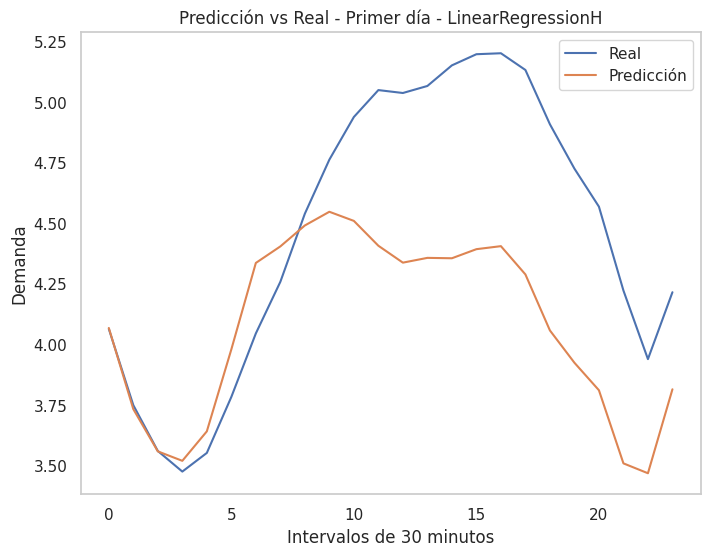

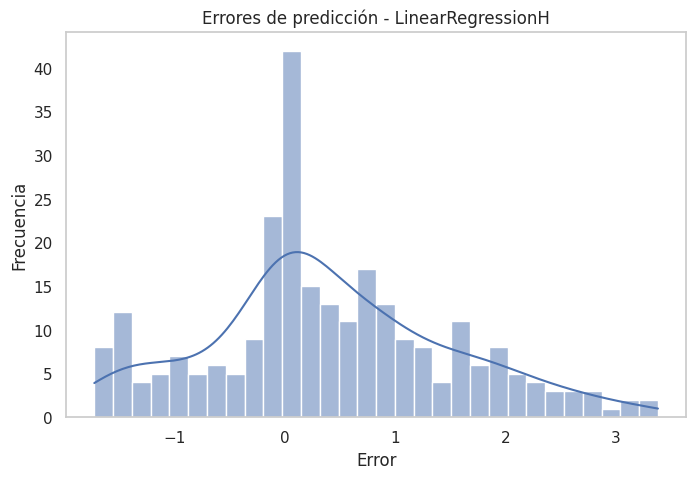


### Entrenando modelo: DecisionTreeRegressorH

MAE: 0.67, MSE: 0.89, RMSE: 0.94, R2: -3.30


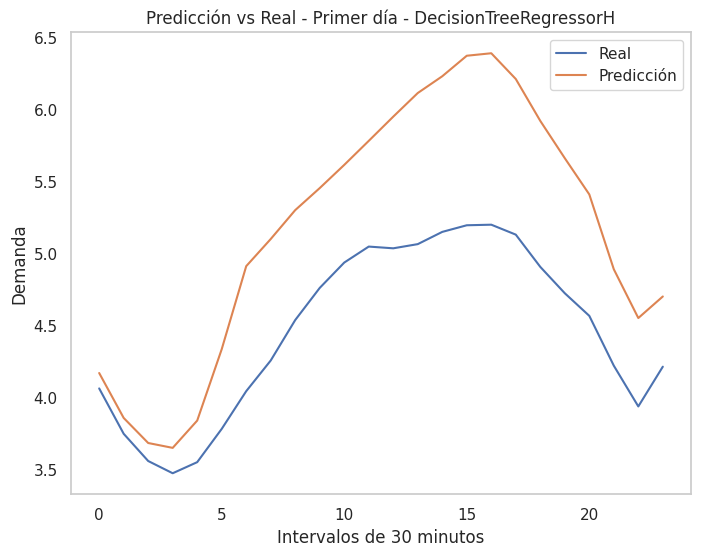

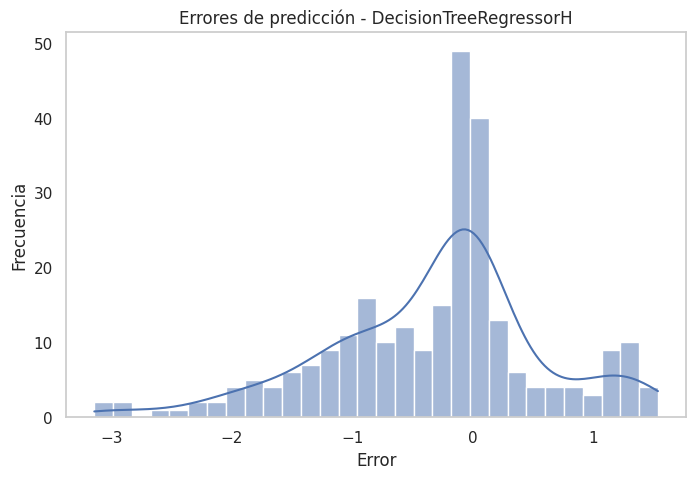


### Entrenando modelo: RandomForestRegressorH

MAE: 0.48, MSE: 0.41, RMSE: 0.64, R2: -1.12


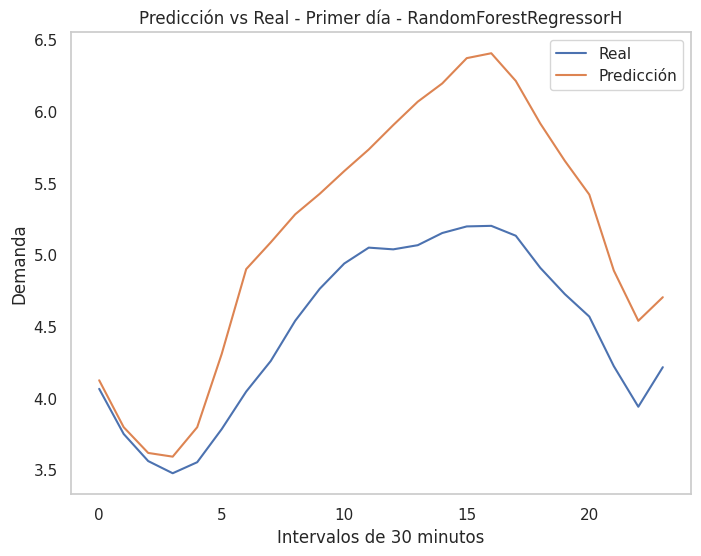

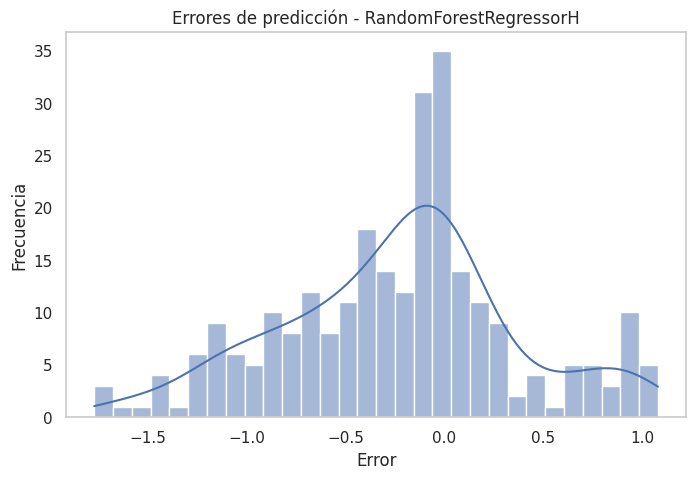


### Entrenando modelo: XGBRegressorH

MAE: 0.51, MSE: 0.51, RMSE: 0.71, R2: -1.86


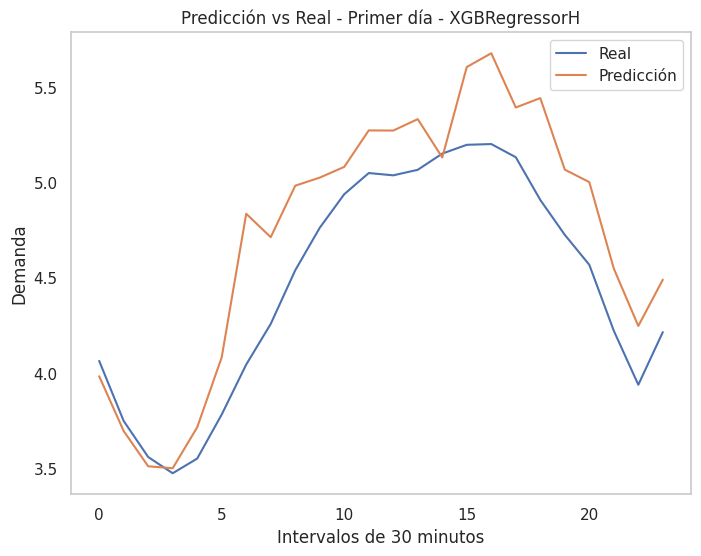

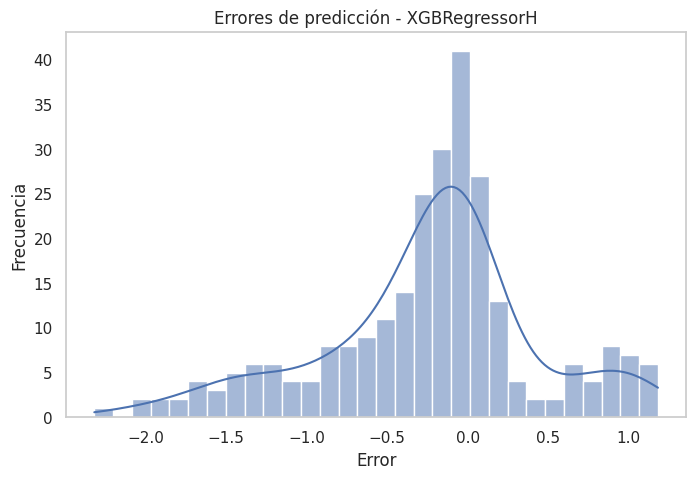

In [14]:
for name, model in models.items():
    print(f"\n### Entrenando modelo: {name}\n")

    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Métricas
        MAE = mean_absolute_error(y_test, y_pred)
        MSE = mean_squared_error(y_test, y_pred)
        RMSE = np.sqrt(MSE)
        R2 = r2_score(y_test, y_pred)

        results["Model"].append(name)
        results["MAE"].append(MAE)
        results["MSE"].append(MSE)
        results["RMSE"].append(RMSE)
        results["R2"].append(R2)

        print(f"MAE: {MAE:.2f}, MSE: {MSE:.2f}, RMSE: {RMSE:.2f}, R2: {R2:.2f}")

        # Guardar modelo
        dump(model, f"modelos-forecasting/{name}.joblib")

        # Visualización de predicción vs real
        plt.figure(figsize=(8,6))
        plt.plot(y_test[0], label="Real")
        plt.plot(y_pred[0], label="Predicción")
        plt.title(f"Predicción vs Real - Primer día - {name}")
        plt.xlabel("Intervalos de 30 minutos")
        plt.ylabel("Demanda")
        plt.legend()
        plt.grid()
        plt.show()

        # Histograma de errores
        residuals = y_test - y_pred
        plt.figure(figsize=(8,5))
        sns.histplot(residuals.flatten(), bins=30, kde=True)
        plt.title(f"Errores de predicción - {name}")
        plt.xlabel("Error")
        plt.ylabel("Frecuencia")
        plt.grid()
        plt.show()

    except Exception as e:
        print(f"Error en modelo {name}: {e}")

In [15]:
# Mostrar resumen de resultados
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2", ascending=False)
results_df


,Model,MAE,MSE,RMSE,R2
2,RandomForestRegressorH,0.483871,0.408427,0.639083,-1.118081
3,XGBRegressorH,0.507421,0.509565,0.713838,-1.862146
1,DecisionTreeRegressorH,0.672397,0.892209,0.944568,-3.295987
0,LinearRegressionH,0.882095,1.380623,1.174999,-5.721888


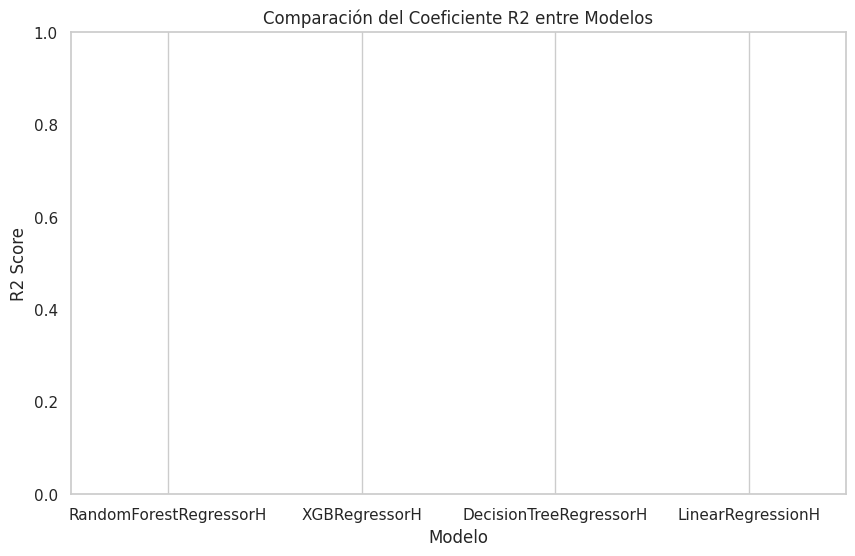

In [16]:
# Comparación de R2
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="R2", data=results_df)
plt.title("Comparación del Coeficiente R2 entre Modelos")
plt.xlabel("Modelo")
plt.ylabel("R2 Score")
plt.ylim(0,1)
plt.grid()
plt.show()

# Explicabiidad global y local

## Local

In [17]:
model = joblib.load("modelos-forecasting/RandomForestRegressorH.joblib")

explainer = shap.Explainer(model)
shap_values = explainer(X_train)

In [18]:
shap.plots.waterfall(shap_values[0])


ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (24, 24)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

## Global

In [ ]:


# Calcular la importancia global promediando los valores absolutos
shap_importance = np.abs(shap_values.values).mean(axis=0)

# Crear DataFrame con la importancia global
importance_df = pd.DataFrame({'Feature': X_train.columns.tolist(), 'SHAP Importance': shap_importance})
importance_df = importance_df.sort_values(by="SHAP Importance", ascending=False)

importance_df

In [ ]:
# Visualización de importancia global de características
shap.summary_plot(shap_values, X_train)


In [ ]:
### Absolute MEAN SHAP

shap.plots.bar(shap_values)